# Introduction to Convolutional Neural Networks and Computer Vision with TensorFlow

Computer vision is the practice of writing algorithms which can discover patterns in visual data . Such as the camera of a self-driving car recognizing the car in front .

The images we're working with are from the Food101 dataset from Kaggle .

However is modified to only use two classes (pizza 🍕 & steak 🥩)

In [1]:
import zipfile

# Get the data 
!wget https://storage.googleapis.com/ztm_tf_course/food_vision/pizza_steak.zip 

# Unzip the downloaded file 
zip_ref = zipfile.ZipFile("pizza_steak.zip")
zip_ref.extractall()
zip_ref.close()

--2026-01-09 18:43:29--  https://storage.googleapis.com/ztm_tf_course/food_vision/pizza_steak.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 74.125.135.207, 74.125.142.207, 74.125.195.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|74.125.135.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 109540975 (104M) [application/zip]
Saving to: ‘pizza_steak.zip’

pizza_steak.zip     100%[===================>] 104.47M   260MB/s    in 0.4s    

2026-01-09 18:43:30 (260 MB/s) - ‘pizza_steak.zip’ saved [109540975/109540975]



Inspect the data

In [2]:
!ls pizza_steak

test  train


In [3]:
!ls pizza_steak/train

pizza  steak


In [4]:
!ls pizza_steak/train/steak

1000205.jpg  1647351.jpg  2238681.jpg  2824680.jpg  3375959.jpg  417368.jpg
100135.jpg   1650002.jpg  2238802.jpg  2825100.jpg  3381560.jpg  4176.jpg
101312.jpg   165639.jpg   2254705.jpg  2826987.jpg  3382936.jpg  42125.jpg
1021458.jpg  1658186.jpg  225990.jpg   2832499.jpg  3386119.jpg  421476.jpg
1032846.jpg  1658443.jpg  2260231.jpg  2832960.jpg  3388717.jpg  421561.jpg
10380.jpg    165964.jpg   2268692.jpg  285045.jpg   3389138.jpg  438871.jpg
1049459.jpg  167069.jpg   2271133.jpg  285147.jpg   3393547.jpg  43924.jpg
1053665.jpg  1675632.jpg  227576.jpg   2855315.jpg  3393688.jpg  440188.jpg
1068516.jpg  1678108.jpg  2283057.jpg  2856066.jpg  3396589.jpg  442757.jpg
1068975.jpg  168006.jpg   2286639.jpg  2859933.jpg  339891.jpg	 443210.jpg
1081258.jpg  1682496.jpg  2287136.jpg  286219.jpg   3417789.jpg  444064.jpg
1090122.jpg  1684438.jpg  2291292.jpg  2862562.jpg  3425047.jpg  444709.jpg
1093966.jpg  168775.jpg   229323.jpg   2865730.jpg  3434983.jpg  447557.jpg
1098844.jpg  1697

In [5]:
import os 

# Walk through pizza_steak directory and list number of files
for dirpath , dirname , filenames in os.walk("pizza_steak"):
    print(f"There are {len(dirname)} directories and {len(filenames)} images in '{dirpath}'")

There are 2 directories and 0 images in 'pizza_steak'
There are 2 directories and 0 images in 'pizza_steak/test'
There are 0 directories and 250 images in 'pizza_steak/test/steak'
There are 0 directories and 250 images in 'pizza_steak/test/pizza'
There are 2 directories and 0 images in 'pizza_steak/train'
There are 0 directories and 750 images in 'pizza_steak/train/steak'
There are 0 directories and 750 images in 'pizza_steak/train/pizza'


In [6]:
# Another way to find out how many images are in a file 
num_steak_images = len(os.listdir("pizza_steak/train/steak"))

num_steak_images

750

To visualize our images , first let's get the class names programmatically .

In [7]:
# Get the class names programmatically
import pathlib
import numpy as np

data_dir = pathlib.Path("pizza_steak/train")
class_names = np.array(sorted([item.name for item in data_dir.glob("*")])) # Create a list of class names from the subdirectories 

print(class_names)

['pizza' 'steak']


In [8]:
# Let's visualize our images
import matplotlib.pyplot as plt 
import matplotlib.image as mpimg
import random

def view_random_image(target_dir , target_class) :
    # Setup the target dir 
    target_folder = target_dir + target_class
    
    # Get random image 
    random_image = random.sample(os.listdir(target_folder),1)
    
    # Read in the image and plot it using matplotlib
    img = mpimg.imread(target_folder + "/" + random_image[0])
    
    plt.imshow(img)
    plt.title(target_class)
    plt.axis("off")
    print(f"Image shape: {img.shape}") # show the shape of the image
    
    return img

Image shape: (512, 512, 3)


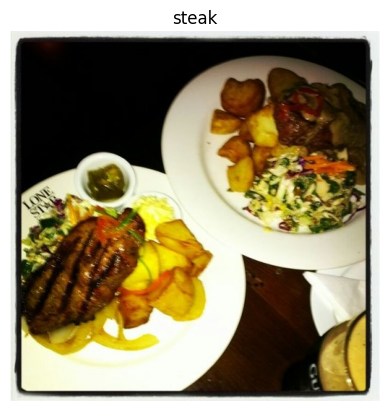

In [20]:
# View a random image from the training dataset
img = view_random_image("pizza_steak/train/" , "steak")

Image shape: (512, 512, 3)


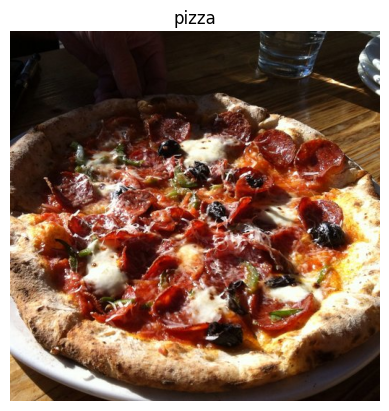

In [23]:
img2 = view_random_image("pizza_steak/train/", "pizza")

In [11]:
import tensorflow as tf 

tf.constant(img)

<tf.Tensor: shape=(512, 512, 3), dtype=uint8, numpy=
array([[[178, 195, 238],
        [177, 194, 237],
        [176, 193, 236],
        ...,
        [176, 177, 241],
        [170, 184, 247],
        [158, 179, 242]],

       [[175, 192, 235],
        [176, 193, 236],
        [177, 194, 237],
        ...,
        [168, 168, 232],
        [169, 183, 246],
        [163, 183, 246]],

       [[170, 187, 230],
        [173, 190, 233],
        [176, 193, 236],
        ...,
        [161, 156, 220],
        [163, 173, 235],
        [165, 181, 243]],

       ...,

       [[108,  41,  92],
        [106,  42,  94],
        [102,  42,  94],
        ...,
        [195, 136, 140],
        [195, 136, 140],
        [197, 138, 142]],

       [[118,  11,  65],
        [126,  22,  75],
        [134,  33,  89],
        ...,
        [194, 138, 141],
        [191, 132, 136],
        [189, 130, 134]],

       [[138,  11,  66],
        [139,  14,  70],
        [139,  20,  76],
        ...,
        [193, 137, 14

In [12]:
# View the image shape 
img.shape # returns width , height , color_channels


(512, 512, 3)

## An end-to-end example 

Let's build a convolutional neural network to find patterns in our images , more specifically we a need way to :

* Load our iamges 
* Preprocess our images 
* Build a CNN to find patterns in our images
* Compile our CNN
* Fit the CNN to our training data 

In [13]:
train_dir = "pizza_steak/train/"
test_dir = "pizza_steak/test/"

In [14]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Set the seed 
tf.random.set_seed(42)

# Preprocess the data (get all of the pixel values between 0 and 1)
train_datagen = ImageDataGenerator(rescale=1./255.)
valid_datagen = ImageDataGenerator(rescale=1./255.)

# Import data from directories and turn it into batches 
train_data = train_datagen.flow_from_directory(directory=train_dir,
                                               batch_size=32,
                                               target_size=(244,244),
                                               class_mode="binary",
                                               seed=42)

valid_data = valid_datagen.flow_from_directory(directory=test_dir,
                                               batch_size=32,
                                               target_size=(244,244),
                                               class_mode="binary",
                                               seed=42)

# Build a CNN model
model_1 = tf.keras.Sequential([
    tf.keras.layers.Conv2D(filters=10 , 
                           kernel_size=3 ,
                           activation="relu",
                           input_shape=(244,244,3)),
    tf.keras.layers.Conv2D(10 , 3 , activation="relu"),
    tf.keras.layers.MaxPool2D(pool_size=2 , padding="valid"),
    tf.keras.layers.Conv2D(10 , 3 , activation="relu"),
    tf.keras.layers.Conv2D(10 , 3 , activation="relu"),
    tf.keras.layers.MaxPool2D(2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(1 , activation="sigmoid")
])

# Compile our CNN
model_1.compile(loss="binary_crossentropy",
                optimizer=tf.keras.optimizers.Adam(),
                metrics=["accuracy"])

# Fit the model
history_1 = model_1.fit(train_data,
                        epochs=5,
                        steps_per_epoch=len(train_data),
                        validation_data=valid_data,
                        validation_steps=len(valid_data))

Found 1500 images belonging to 2 classes.
Found 500 images belonging to 2 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


47/47 ━━━━━━━━━━━━━━━━━━━━ 17s 231ms/step - accuracy: 0.5940 - loss: 0.6674 - val_accuracy: 0.8140 - val_loss: 0.4579
Epoch 2/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 105ms/step - accuracy: 0.7570 - loss: 0.4826 - val_accuracy: 0.8480 - val_loss: 0.3894
Epoch 3/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 115ms/step - accuracy: 0.8013 - loss: 0.4381 - val_accuracy: 0.8100 - val_loss: 0.3844
Epoch 4/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 107ms/step - accuracy: 0.8317 - loss: 0.4084 - val_accuracy: 0.8720 - val_loss: 0.3662
Epoch 5/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 6s 137ms/step - accuracy: 0.8603 - loss: 0.3387 - val_accuracy: 0.8700 - val_loss: 0.3226


In [15]:
# Get a model summary
model_1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 242, 242, 10)   │           280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 240, 240, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 120, 120, 10)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 118, 118, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 116, 116, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 58, 58, 10)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 33640)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │        33,641 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,955 (429.52 KB)

 Trainable params: 36,651 (143.17 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 73,304 (286.35 KB)

In [26]:
# Set random seed
tf.random.set_seed(42)

# Create a model 
model_2 = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(244,244,3)),
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(1 , activation="sigmoid")
])

# Compile the model
model_2.compile(loss="binary_crossentropy",
                optimizer=tf.keras.optimizers.Adam(),
                metrics=["accuracy"])

# Fit the model
history_2 = model_2.fit(train_data,
                        epochs=5,
                        steps_per_epoch=len(train_data),
                        validation_data=valid_data,
                        validation_steps=len(valid_data))

Epoch 1/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 9s 145ms/step - accuracy: 0.5383 - loss: 1.3892 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 2/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 105ms/step - accuracy: 0.5014 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 3/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 100ms/step - accuracy: 0.4917 - loss: 0.6933 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 4/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 113ms/step - accuracy: 0.4995 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 5/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 96ms/step - accuracy: 0.4808 - loss: 0.6934 - val_accuracy: 0.5000 - val_loss: 0.6932


In [27]:
model_2.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_4 (Flatten)             │ (None, 178608)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 4)              │       714,436 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 4)              │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,143,385 (8.18 MB)

 Trainable params: 714,461 (2.73 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,428,924 (5.45 MB)

In [28]:
# Set random seed
tf.random.set_seed(42)

# Create a model 
model_3 = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(244,244,3)),
    tf.keras.layers.Dense(100, activation="relu"),
    tf.keras.layers.Dense(100, activation="relu"),
    tf.keras.layers.Dense(100, activation="relu"),
    tf.keras.layers.Dense(1 , activation="sigmoid")
])

# Compile the model
model_3.compile(loss="binary_crossentropy",
                optimizer=tf.keras.optimizers.Adam(),
                metrics=["accuracy"])

# Fit the model
history_3 = model_3.fit(train_data,
                        epochs=5,
                        steps_per_epoch=len(train_data),
                        validation_data=valid_data,
                        validation_steps=len(valid_data))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 9s 145ms/step - accuracy: 0.5780 - loss: 5.4375 - val_accuracy: 0.6420 - val_loss: 1.4871
Epoch 2/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 110ms/step - accuracy: 0.6558 - loss: 1.1688 - val_accuracy: 0.5700 - val_loss: 1.2142
Epoch 3/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 102ms/step - accuracy: 0.7054 - loss: 0.7199 - val_accuracy: 0.7800 - val_loss: 0.4430
Epoch 4/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 110ms/step - accuracy: 0.7780 - loss: 0.5077 - val_accuracy: 0.5480 - val_loss: 0.8333
Epoch 5/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 96ms/step - accuracy: 0.7017 - loss: 0.7842 - val_accuracy: 0.7400 - val_loss: 0.6506


In [29]:
model_3.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_5 (Flatten)             │ (None, 178608)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 100)            │    17,860,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 53,643,605 (204.63 MB)

 Trainable params: 17,881,201 (68.21 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 35,762,404 (136.42 MB)

## Binary Classification : Let's break it down

1. Understand the data (visualize)
2. Prepocess the data (prepared it for our model)
3. Created a model (start with a baseline)
4. Fit the model
5. Evaluate the model
6. Adjust different parameters and improve the model (try to beat our baseline)
7. Repeat until satisfied (experiment)

Image shape: (382, 512, 3)
Image shape: (512, 512, 3)


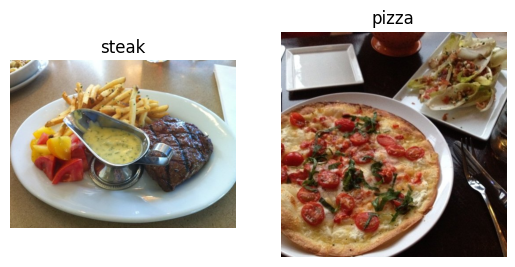

In [30]:
# Visualize data
plt.figure()
plt.subplot(1 , 2, 1)
steak_img = view_random_image("pizza_steak/train/" , "steak")
plt.subplot(1 , 2 , 2)
pizza_img = view_random_image("pizza_steak/train/" , "pizza")

In [31]:
# Preprocess the data 

# Define directory dataset paths
train_dir = "pizza_steak/train/"
test_dir = "pizza_steak/test/"

In [35]:
# Turn data into batches
# Create train and test data generators and rescale the data 
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(rescale=1./255.)
test_datagen = ImageDataGenerator(rescale=1./255.)

# Load in our image data from directories and turn them into batches
train_data = train_datagen.flow_from_directory(directory=train_dir, # Target dir of images
                                               target_size=(244,244), # Target size of images
                                               class_mode="binary", # Type of data you're working with
                                               batch_size=32) # size of mini-batches to load data into

test_data = test_datagen.flow_from_directory(directory=test_dir,
                                             target_size=(244,244),
                                             class_mode="binary",
                                             batch_size=32)

Found 1500 images belonging to 2 classes.
Found 500 images belonging to 2 classes.


In [37]:
# Get a sample of a train data batch
images , labels = next(train_data) # get next batch of images and labels
len(images) , len(labels)

(32, 32)

In [38]:
# Get the first 2 images
images[:2] , images[0].shape

(array([[[[0.7568628 , 0.75294125, 0.8235295 ],
          [0.8117648 , 0.8196079 , 0.87843144],
          [0.6784314 , 0.6862745 , 0.74509805],
          ...,
          [0.79215693, 0.8078432 , 0.85098046],
          [0.78823537, 0.80392164, 0.8470589 ],
          [0.74509805, 0.7607844 , 0.80392164]],
 
         [[0.75294125, 0.7490196 , 0.8196079 ],
          [0.8078432 , 0.81568635, 0.8745099 ],
          [0.6666667 , 0.6784314 , 0.7372549 ],
          ...,
          [0.8117648 , 0.82745105, 0.8705883 ],
          [0.81568635, 0.8313726 , 0.8745099 ],
          [0.7843138 , 0.8000001 , 0.8431373 ]],
 
         [[0.74509805, 0.7490196 , 0.8196079 ],
          [0.8117648 , 0.81568635, 0.8862746 ],
          [0.654902  , 0.6666667 , 0.7254902 ],
          ...,
          [0.81568635, 0.8313726 , 0.8745099 ],
          [0.82745105, 0.8431373 , 0.8862746 ],
          [0.8117648 , 0.82745105, 0.8705883 ]],
 
         ...,
 
         [[0.8196079 , 0.8235295 , 0.83921576],
          [0.81568

In [39]:
# View the first batch of labels
labels

array([1., 1., 1., 1., 0., 1., 0., 0., 1., 1., 1., 1., 0., 1., 1., 1., 1.,
       0., 0., 0., 0., 1., 0., 0., 0., 1., 0., 1., 0., 1., 0., 1.],
      dtype=float32)